In [1]:
import os
os.getcwd()

'C:\\Users\\Sepand\\Desktop\\Equity-Risk-Forecasting-Project\\Day4_MonteCarlo_VaR'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

kpi = pd.read_csv("../data_clean/kpi_summary.csv")

annual_return = float(kpi.loc[kpi["metric"]=="annual_return","value"])
annual_vol = float(kpi.loc[kpi["metric"]=="annual_volatility","value"])

annual_return, annual_vol

C:\Users\Sepand\AppData\Local\Temp\ipykernel_13424\3725337869.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  annual_return = float(kpi.loc[kpi["metric"]=="annual_return","value"])
C:\Users\Sepand\AppData\Local\Temp\ipykernel_13424\3725337869.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  annual_vol = float(kpi.loc[kpi["metric"]=="annual_volatility","value"])


(0.3735980797003546, 0.2742997639726725)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

kpi = pd.read_csv("../data_clean/kpi_summary.csv")

annual_return = kpi.loc[kpi["metric"]=="annual_return", "value"].iloc[0]
annual_vol = kpi.loc[kpi["metric"]=="annual_volatility", "value"].iloc[0]

annual_return, annual_vol

(np.float64(0.3735980797003546), np.float64(0.2742997639726725))

In [4]:
# Monte Carlo settings
n_sims = 100_000
seed = 42
np.random.seed(seed)

mu = annual_return
sigma = annual_vol

# Simulated 1-year returns (Normal assumption)
sim_1y_returns = np.random.normal(loc=mu, scale=sigma, size=n_sims)

# Quick checks
sim_1y_returns.mean(), sim_1y_returns.std()

(np.float64(0.37386329140320973), np.float64(0.27454689552311107))

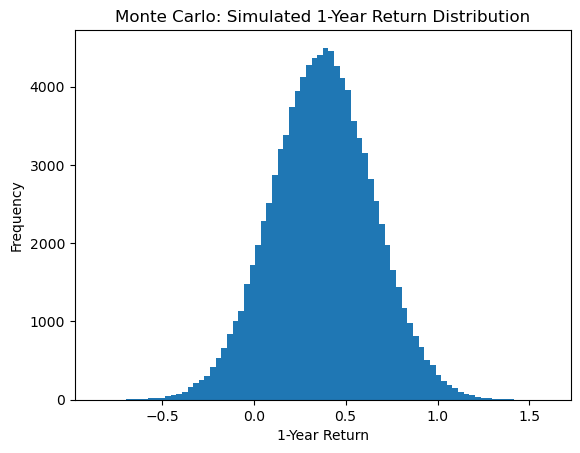

In [5]:
plt.figure()
plt.hist(sim_1y_returns, bins=80)
plt.title("Monte Carlo: Simulated 1-Year Return Distribution")
plt.xlabel("1-Year Return")
plt.ylabel("Frequency")
plt.show()

In [6]:
# Value at Risk (Monte Carlo)
var_95_mc = -np.percentile(sim_1y_returns, 5)
var_99_mc = -np.percentile(sim_1y_returns, 1)

var_95_mc, var_99_mc

(np.float64(0.07721059808421053), np.float64(0.26679634095367394))

In [7]:
# Conditional VaR (Expected Shortfall)
cvar_95_mc = -sim_1y_returns[sim_1y_returns <= np.percentile(sim_1y_returns, 5)].mean()
cvar_99_mc = -sim_1y_returns[sim_1y_returns <= np.percentile(sim_1y_returns, 1)].mean()

cvar_95_mc, cvar_99_mc

(np.float64(0.19278076224737478), np.float64(0.35892772261000766))

In [8]:
# Parametric VaR from Day 3 formula
var_95_param = -(annual_return - 1.65 * annual_vol)

var_95_param

np.float64(0.07899653085455499)

In [9]:
var_95_param, var_95_mc

(np.float64(0.07899653085455499), np.float64(0.07721059808421053))

In [10]:
mc_summary = pd.DataFrame({
    "metric": [
        "MC_VaR_95",
        "MC_VaR_99",
        "MC_CVaR_95",
        "MC_CVaR_99"
    ],
    "value": [
        var_95_mc,
        var_99_mc,
        cvar_95_mc,
        cvar_99_mc
    ]
})

mc_summary.to_csv("../data_clean/monte_carlo_risk_summary.csv", index=False)

mc_summary

,metric,value
0,MC_VaR_95,0.077211
1,MC_VaR_99,0.266796
2,MC_CVaR_95,0.192781
3,MC_CVaR_99,0.358928


In [11]:
print("MC VaR 95:", var_95_mc)
print("MC CVaR 95:", cvar_95_mc)
print("Parametric VaR 95:", var_95_param)

MC VaR 95: 0.07721059808421053
MC CVaR 95: 0.19278076224737478
Parametric VaR 95: 0.07899653085455499


In [12]:
sim_df = pd.DataFrame({
    "simulated_1y_return": sim_1y_returns
})

sim_df.to_csv("../data_clean/monte_carlo_distribution.csv", index=False)

print("Monte Carlo distribution saved.")

Monte Carlo distribution saved.
